In [3]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('../data/airbnb_london.csv')

print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))

Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [4]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))

95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


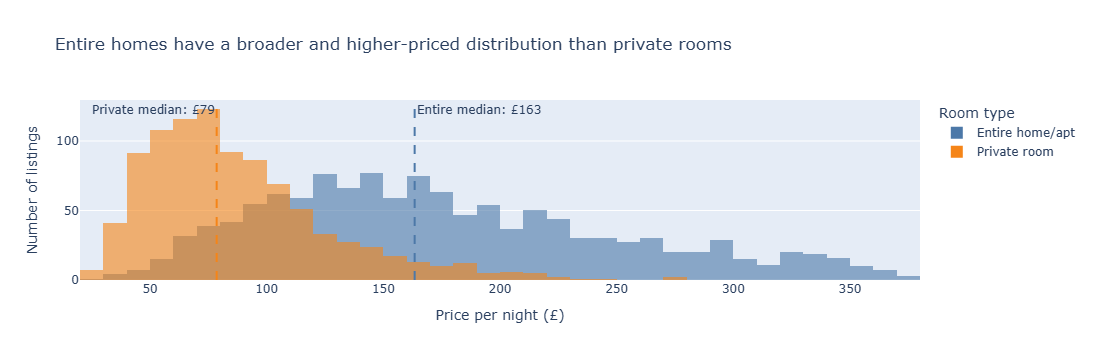

In [15]:
#Task1
# Keep only the two main room types
hist_df = df_cap[
    df_cap['room_type'].isin(['Entire home/apt', 'Private room'])
]

# Calculate medians
entire_median = hist_df[
    hist_df['room_type'] == 'Entire home/apt'
]['price'].median()

private_median = hist_df[
    hist_df['room_type'] == 'Private room'
]['price'].median()

# Histogram
fig = px.histogram(
    hist_df,
    x='price',
    color='room_type',
    barmode='overlay',
    opacity=0.6,
    nbins=40,
    color_discrete_map={
        'Entire home/apt': '#4C78A8',
        'Private room': '#F58518'
    },
    title='Entire homes have a broader and higher-priced distribution than private rooms'
)

# Median reference lines
fig.add_vline(
    x=entire_median,
    line_dash='dash',
    line_color='#4C78A8',
    annotation_text=f'Entire median: £{entire_median:.0f}',
    annotation_position='top right'
)

fig.add_vline(
    x=private_median,
    line_dash='dash',
    line_color='#F58518',
    annotation_text=f'Private median: £{private_median:.0f}',
    annotation_position='top left'
)

# Layout updates
fig.update_layout(
    xaxis_title='Price per night (£)',
    yaxis_title='Number of listings',
    legend_title='Room type'
)

fig.show()

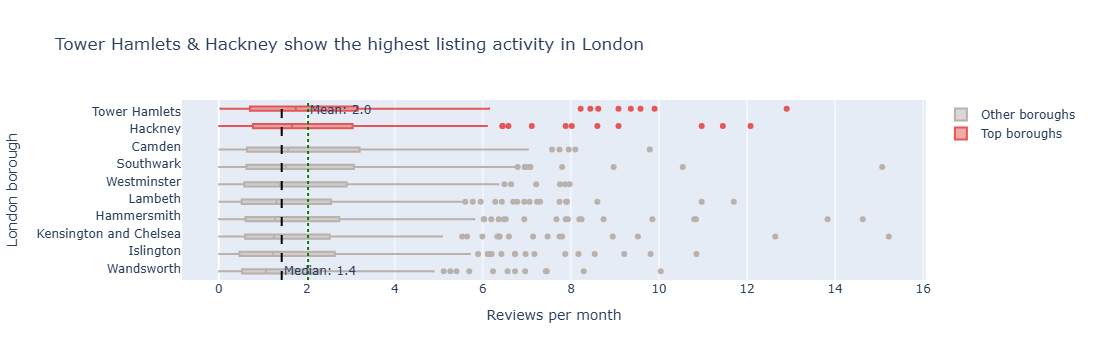

In [16]:
# Task 2 — Remove inactive or new listings
activity_df = df[df['reviews_per_month'] > 0].copy()

# Sort boroughs by median reviews per month
borough_order = (
    activity_df.groupby('neighbourhood')['reviews_per_month']
    .median()
    .sort_values(ascending=False)
    .index
)

# Top 2 most active boroughs
top2 = borough_order[:2]

# Highlight top boroughs
activity_df['highlight'] = np.where(
    activity_df['neighbourhood'].isin(top2),
    'Top boroughs',
    'Other boroughs'
)

# Box plot
fig = px.box(
    activity_df,
    x='reviews_per_month',
    y='neighbourhood',
    color='highlight',
    orientation='h',
    points='outliers',
    category_orders={
        'neighbourhood': borough_order
    },
    color_discrete_map={
        'Top boroughs': '#E45756',
        'Other boroughs': '#BAB0AC'
    },
    title=f"{' & '.join(top2)} show the highest listing activity in London"
)

# Mean and median reference lines
mean_reviews = activity_df['reviews_per_month'].mean()
median_reviews = activity_df['reviews_per_month'].median()

fig.add_vline(
    x=mean_reviews,
    line_dash='dot',
    line_color='green',
    annotation_text=f'Mean: {mean_reviews:.1f}',
    annotation_position='top right'
)

fig.add_vline(
    x=median_reviews,
    line_dash='dash',
    line_color='black',
    annotation_text=f'Median: {median_reviews:.1f}',
    annotation_position='bottom right'
)

# Layout updates
fig.update_layout(
    xaxis_title='Reviews per month',
    yaxis_title='London borough',
    legend_title=''
)

fig.show()